# 🤖 Machine Learning Model Training and Evaluation

This notebook trains and evaluates multiple machine learning classification models using the preprocessed Bank Marketing dataset.

The following models will be implemented:

1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbors (KNN)
4. Gaussian Naive Bayes
5. Random Forest Classifier

Each model is evaluated using:

- Accuracy
- AUC Score
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Models
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Load Processed Data

Load the processed datasets generated during the Data Preparation stage.

In [12]:
# Load the raw train/test CSVs created from bank.csv
from pathlib import Path

project_root = Path.cwd()
for candidate in [project_root, *project_root.parents]:
    if (candidate / "bank.csv").exists():
        project_root = candidate
        break

output_dir = project_root / "data"
output_dir.mkdir(exist_ok=True, parents=True)

train_df = pd.read_csv(project_root / "train.csv")
test_df = pd.read_csv(project_root / "test.csv")

X_train_raw = train_df.drop(columns=["deposit"])
X_test_raw = test_df.drop(columns=["deposit"])

y_train = train_df["deposit"].map({"no": 0, "yes": 1})
y_test = test_df["deposit"].map({"no": 0, "yes": 1})

numerical_features = X_train_raw.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train_raw.select_dtypes(include=["object", "category"]).columns

X_train_encoded = pd.get_dummies(X_train_raw, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_raw, columns=categorical_features, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0,
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train_encoded[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test_encoded[numerical_features])

# Save the processed files for reuse and consistency
X_train_encoded.to_csv(output_dir / "X_train_encoded.csv", index=False)
X_test_encoded.to_csv(output_dir / "X_test_encoded.csv", index=False)
X_train_scaled.to_csv(output_dir / "X_train_scaled.csv", index=False)
X_test_scaled.to_csv(output_dir / "X_test_scaled.csv", index=False)
pd.Series(y_train, name="deposit").to_csv(output_dir / "y_train_encoded.csv", index=False)
pd.Series(y_test, name="deposit").to_csv(output_dir / "y_test_encoded.csv", index=False)

X_train_encoded = X_train_scaled
X_test_encoded = X_test_scaled

## Helper Functions

In [3]:
# ==========================================
# Evaluate Model
# ==========================================

def evaluate_model(model, X_test, y_test):
    """
    Evaluate a trained classification model.
    """

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }

    return metrics, y_pred

# ==========================================
# Print Metrics
# ==========================================

def display_metrics(model_name, metrics):
    """
    Display evaluation metrics.
    """

    print("=" * 55)
    print(model_name)
    print("=" * 55)

    print("\nEvaluation Metrics:")
    for metric, value in metrics.items():
        print(f"{metric:<12}: {value:.4f}")

# ==========================================
# Plot Confusion Matrix
# ==========================================

def plot_confusion_matrix(model_name, y_test, y_pred, cmap="Blues"):
    """
    Plot confusion matrix.
    """

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        linewidths=0.5,
        cbar=False
    )

    plt.title(
        f"{model_name} - Confusion Matrix",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# ==========================================
# Save Model
# ==========================================

def save_model(model, filename):
    """
    Save trained model.
    """

    os.makedirs("../models", exist_ok=True)

    joblib.dump(
        model,
        f"../models/{filename}"
    )

    print(f"✅ {filename} saved successfully.")

# ==========================================
# Results Table
# ==========================================

results = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "AUC",
        "Precision",
        "Recall",
        "F1 Score",
        "MCC"
    ]
)

def add_results(results, model_name, metrics):
    """
    Add model metrics to comparison table.
    """

    results.loc[len(results)] = [
        model_name,
        metrics["Accuracy"],
        metrics["AUC"],
        metrics["Precision"],
        metrics["Recall"],
        metrics["F1 Score"],
        metrics["MCC"]
    ]

    return results

## Logistic Regression

✅ Logistic Regression model trained successfully.
Logistic Regression

Evaluation Metrics:
Accuracy    : 0.8253
AUC         : 0.9073
Precision   : 0.8275
Recall      : 0.7977
F1 Score    : 0.8123
MCC         : 0.6495

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1175
           1       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.82      2233
weighted avg       0.83      0.83      0.83      2233



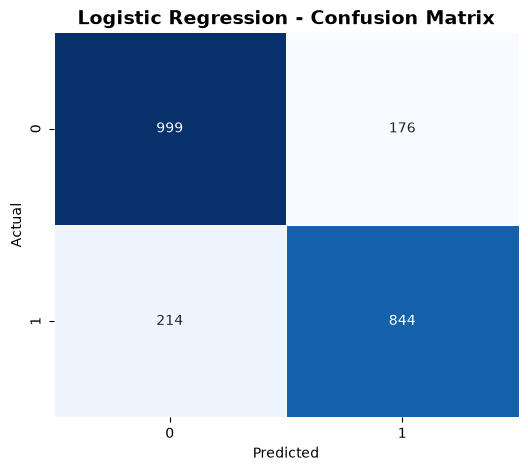

✅ logistic.pkl saved successfully.


In [4]:
# ==========================================
# Logistic Regression Model
# ==========================================

logistic_model = LogisticRegression(
    penalty="l2",              # L2 Regularization
    C=1.0,                     # Inverse regularization strength
    max_iter=1000,             # Maximum iterations
    tol=1e-4,                  # Convergence tolerance
    fit_intercept=True,        # Learn intercept term
    random_state=42,           # Ensures reproducibility
)

logistic_model.fit(X_train_scaled, y_train)

print("✅ Logistic Regression model trained successfully.")

metrics, predictions = evaluate_model(
    logistic_model,
    X_test_scaled,
    y_test
)

display_metrics("Logistic Regression", metrics)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

plot_confusion_matrix(
    "Logistic Regression",
    y_test,
    predictions,
    cmap="Blues"
)

save_model(
    logistic_model,
    "logistic.pkl"
)

results = add_results(
    results,
    "Logistic Regression",
    metrics
)

## Decision Tree Classifier

✅ Decision Tree model trained successfully.
Decision Tree

Evaluation Metrics:
Accuracy    : 0.8249
AUC         : 0.8944
Precision   : 0.7843
Recall      : 0.8696
F1 Score    : 0.8247
MCC         : 0.6542

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.78      0.83      1175
           1       0.78      0.87      0.82      1058

    accuracy                           0.82      2233
   macro avg       0.83      0.83      0.82      2233
weighted avg       0.83      0.82      0.82      2233



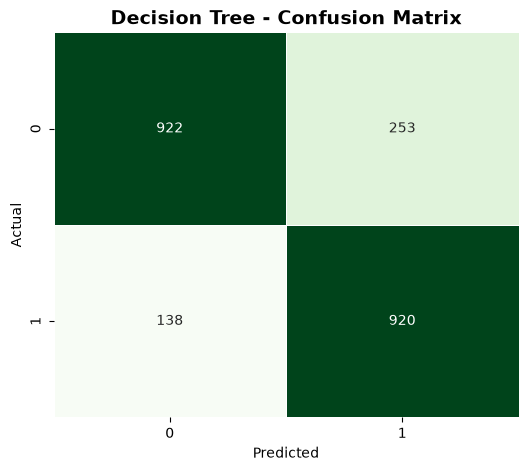

✅ decision_tree.pkl saved successfully.


In [5]:
# ==========================================
# Train Decision Tree Classifier
# ==========================================

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

decision_tree_model.fit(X_train_encoded, y_train)

print("✅ Decision Tree model trained successfully.")

metrics, predictions = evaluate_model(
    decision_tree_model,
    X_test_encoded,
    y_test
)

display_metrics("Decision Tree", metrics)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

plot_confusion_matrix(
    "Decision Tree",
    y_test,
    predictions,
    cmap="Greens"
)

save_model(
    decision_tree_model,
    "decision_tree.pkl"
)

results = add_results(
    results,
    "Decision Tree",
    metrics
)

## K-Nearest Neighbors (KNN)

✅ K-Nearest Neighbors model trained successfully.
K-Nearest Neighbors

Evaluation Metrics:
Accuracy    : 0.8285
AUC         : 0.8923
Precision   : 0.8280
Recall      : 0.8053
F1 Score    : 0.8165
MCC         : 0.6558

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1175
           1       0.83      0.81      0.82      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



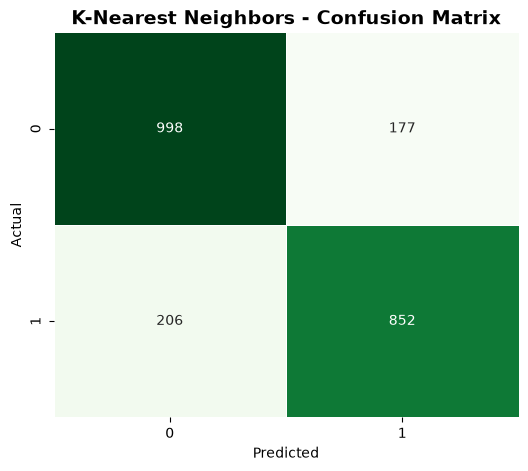

✅ knn.pkl saved successfully.


In [6]:
# ==========================================
# Train K-Nearest Neighbors Classifier
# ==========================================

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    algorithm="auto",
    leaf_size=30,
    metric="minkowski",
    p=2,
    n_jobs=-1
)

knn_model.fit(X_train_scaled, y_train)

print("✅ K-Nearest Neighbors model trained successfully.")

metrics, predictions = evaluate_model(
    knn_model,
    X_test_scaled,
    y_test
)

display_metrics("K-Nearest Neighbors", metrics)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

plot_confusion_matrix(
    "K-Nearest Neighbors",
    y_test,
    predictions,
    cmap="Greens"
)

save_model(
    knn_model,
    "knn.pkl"
)

results = add_results(
    results,
    "K-Nearest Neighbors",
    metrics
)

## Gaussian Naive Bayes

✅ Gaussian Naive Bayes model trained successfully.
Gaussian Naive Bayes

Evaluation Metrics:
Accuracy    : 0.7568
AUC         : 0.8464
Precision   : 0.7877
Recall      : 0.6664
F1 Score    : 0.7220
MCC         : 0.5142

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.84      0.78      1175
           1       0.79      0.67      0.72      1058

    accuracy                           0.76      2233
   macro avg       0.76      0.75      0.75      2233
weighted avg       0.76      0.76      0.75      2233



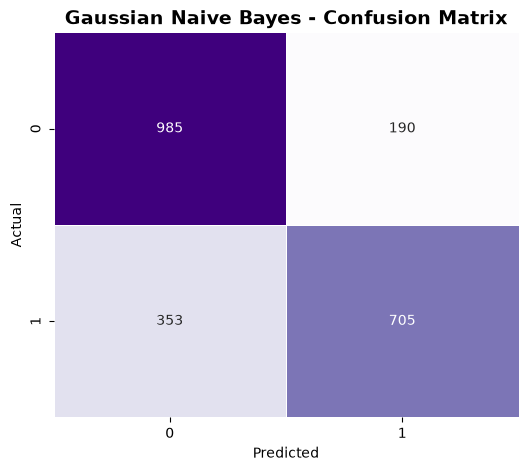

✅ naive_bayes.pkl saved successfully.


In [7]:
# ==========================================
# Train Gaussian Naive Bayes Classifier
# ==========================================

from sklearn.naive_bayes import GaussianNB

naive_bayes_model = GaussianNB(
    priors=None,          # Learn class priors from the training data
    var_smoothing=10e-09    # Adds numerical stability to variance calculations
)

# Train the model
naive_bayes_model.fit(X_train_encoded, y_train)

print("✅ Gaussian Naive Bayes model trained successfully.")

# ==========================================
# Evaluate Model
# ==========================================

metrics, predictions = evaluate_model(
    naive_bayes_model,
    X_test_encoded,
    y_test
)

display_metrics("Gaussian Naive Bayes", metrics)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

# ==========================================
# Confusion Matrix
# ==========================================

plot_confusion_matrix(
    "Gaussian Naive Bayes",
    y_test,
    predictions,
    cmap="Purples"
)

# ==========================================
# Save Model
# ==========================================

save_model(
    naive_bayes_model,
    "naive_bayes.pkl"
)

# ==========================================
# Update Results Table
# ==========================================

results = add_results(
    results,
    "Gaussian Naive Bayes",
    metrics
)

## Random Forest Classifier

✅ Random Forest model trained successfully.
Random Forest

Evaluation Metrics:
Accuracy    : 0.8580
AUC         : 0.9215
Precision   : 0.8236
Recall      : 0.8913
F1 Score    : 0.8561
MCC         : 0.7186

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1175
           1       0.82      0.89      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



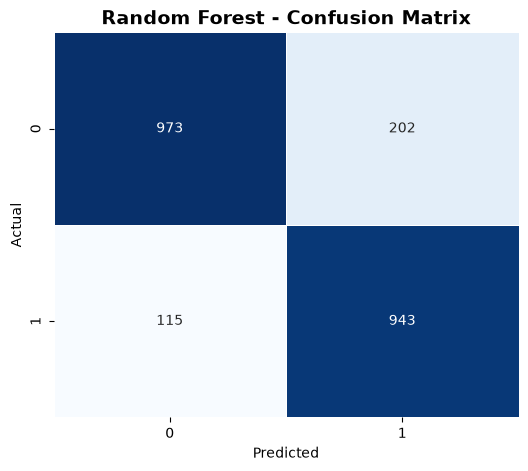


Top 10 Important Features:

             Feature  Importance
3           duration    0.411852
0                age    0.058532
1            balance    0.058284
40  poutcome_success    0.055327
2                day    0.046967
27   contact_unknown    0.046341
5              pdays    0.039551
24       housing_yes    0.033105
4           campaign    0.026130
6           previous    0.023887


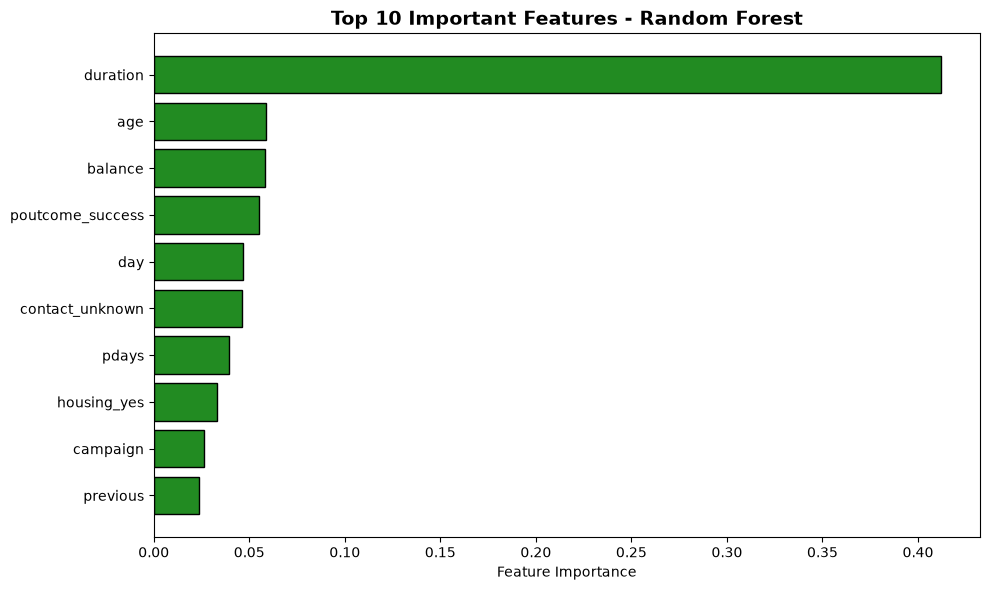

✅ random_forest.pkl saved successfully.


In [8]:
# ==========================================
# Train Random Forest Classifier
# ==========================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,          # Number of trees
    criterion="gini",          # Split criterion
    max_depth=15,              # Maximum tree depth
    min_samples_split=5,       # Minimum samples to split
    min_samples_leaf=2,        # Minimum samples in a leaf
    max_features="sqrt",       # Features considered at each split
    bootstrap=True,            # Bootstrap sampling
    oob_score=True,            # Out-of-Bag score
    n_jobs=-1,                 # Use all CPU cores
    random_state=42
)

# Train the model
random_forest_model.fit(X_train_encoded, y_train)

print("✅ Random Forest model trained successfully.")

# ==========================================
# Evaluate Model
# ==========================================

metrics, predictions = evaluate_model(
    random_forest_model,
    X_test_encoded,
    y_test
)

display_metrics("Random Forest", metrics)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

# ==========================================
# Confusion Matrix
# ==========================================

plot_confusion_matrix(
    "Random Forest",
    y_test,
    predictions,
    cmap="Blues"
)

# ==========================================
# Feature Importance
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features:\n")
print(feature_importance.head(10))

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance.head(10)["Feature"],
    feature_importance.head(10)["Importance"],
    color="forestgreen",
    edgecolor="black"
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Important Features - Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Feature Importance")

plt.tight_layout()

plt.show()

# ==========================================
# Save Model
# ==========================================

save_model(
    random_forest_model,
    "random_forest.pkl"
)

# ==========================================
# Update Results Table
# ==========================================

results = add_results(
    results,
    "Random Forest",
    metrics
)

## MODEL PERFORMANCE COMPARISON

In [9]:
width = 100
title = " MODEL PERFORMANCE COMPARISON "

print("\n" + "=" * width)
print(title.center(width))
print("=" * width)

print(
    results.round(4)
    .sort_values(by=["Accuracy", "AUC"], ascending=False)
    .reset_index(drop=True)
    .to_string(index=False)
)

print("=" * width)


                                    MODEL PERFORMANCE COMPARISON                                    
               Model  Accuracy    AUC  Precision  Recall  F1 Score    MCC
       Random Forest    0.8580 0.9215     0.8236  0.8913    0.8561 0.7186
 K-Nearest Neighbors    0.8285 0.8923     0.8280  0.8053    0.8165 0.6558
 Logistic Regression    0.8253 0.9073     0.8275  0.7977    0.8123 0.6495
       Decision Tree    0.8249 0.8944     0.7843  0.8696    0.8247 0.6542
Gaussian Naive Bayes    0.7568 0.8464     0.7877  0.6664    0.7220 0.5142
